In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.iolib.summary2 import summary_col
from scipy.stats import pearsonr
import os
import locale
from pathlib import Path

from google.colab import drive
# ---------------------------------------------------------------------------
# 1. Setup and Data Loading
# ---------------------------------------------------------------------------
# Mount Google Drive
drive.mount('/content/drive')

# Define folder paths
PROCESSED_DATA_FOLDER = Path("/content/drive/MyDrive/Resilient_Housing_Global_Regression/data_processed")
data_file_path = os.path.join(PROCESSED_DATA_FOLDER, "global_analysis_final_for_modeling.csv")

RESULTS_DATA_FOLDER = Path("/content/drive/MyDrive/Resilient_Housing_Global_Regression/Results")


df_analysis = pd.read_csv(data_file_path, encoding='utf-8-sig', low_memory=False)

dep_var = 'VULN_DEFAULT_ROBUSTNESS'
category_b_vars = [
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE',
    'WB_GDP_PCAP_PPP_INTL_2021_VALUE',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',
    'WB_DB_BUILDING_QUALITY_INDEX'
]
category_c_vars = ['DIS_EQK', 'DIS_STM', 'DIS_FLD']
all_vars = [dep_var] + category_b_vars + category_c_vars

# Create the fixed analysis sample (N=150)
df_stats = df_analysis.dropna(subset=all_vars).copy()

# Apply log transformations
df_stats['log_GDP'] = np.log(df_stats['WB_GDP_PCAP_PPP_INTL_2021_VALUE'])
df_stats['log_DIS_EQK'] = np.log1p(df_stats['DIS_EQK'])
df_stats['log_DIS_STM'] = np.log1p(df_stats['DIS_STM'])
df_stats['log_DIS_FLD'] = np.log1p(df_stats['DIS_FLD'])
df_stats['log_Land_Area'] = np.log1p(df_stats['WB_LAND_AREA_SQ_KM_VALUE'])
df_stats['log_POP'] = np.log1p(df_stats['WB_POPULATION_TOTAL_VALUE'])

df_stats['DIS_3_HAZARDS'] = df_stats[['DIS_EQK', 'DIS_STM', 'DIS_FLD']].sum(axis=1)
df_stats['log_DIS_3_HAZARDS'] = np.log1p(df_stats['DIS_3_HAZARDS'])

print(f"✅ Analysis Sample Fixed: N = {len(df_stats)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Analysis Sample Fixed: N = 150


# Summary Statistics

In [8]:
# -----------------------------------------------------------------------------
# 2. SUMMARY STATISTICS CALCULATION
# -----------------------------------------------------------------------------

#Key variables to include in the summary stats
category_a_vars = ['VULN_DEFAULT_ROBUSTNESS', 'VULN_DEFAULT_ROBUST_ONLY']
category_b_vars = [
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE',
    'WB_GDP_PCAP_PPP_INTL_2021_VALUE',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',
    'WB_DB_BUILDING_QUALITY_INDEX',
]
category_c_vars = [
    'DIS_EQK',
    'DIS_STM',
    'DIS_FLD',
]


summary_vars = category_a_vars + category_b_vars + category_c_vars
summary_stats = df_stats[summary_vars].describe().T
summary_stats = summary_stats[['count', 'mean', 'std', 'min', 'max']]
summary_stats.columns = ['N', 'Mean', 'Std. Dev.', 'Min', 'Max']

# -----------------------------------------------------------------------------
# 3. FORMATTING AND DISPLAY
# -----------------------------------------------------------------------------

variable_label_map_en = {
    'VULN_DEFAULT_ROBUSTNESS': 'Combined Hazards (Robust or Medium)',
    'VULN_DEFAULT_ROBUST_ONLY': 'Combined Hazards (Robust Only)',
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE': 'Poverty Gap (%, $4.20/day, 2021 PPP)',
    'WB_GDP_PCAP_PPP_INTL_2021_VALUE': 'GDP per Capita (PPP, Intl $2021) - RAW',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE': 'Government Effectiveness (WGI, 2024)',
    'WB_DB_BUILDING_QUALITY_INDEX': 'Building Quality Index (0-15, Doing Business 2020)',
    'DIS_EQK': 'Earthquake Events ',
    'DIS_STM': 'Storm Events ',
    'DIS_FLD': 'Flood Events ',
}

raw_variables_for_int_format = ['WB_GDP_PCAP_PPP_INTL_2021_VALUE', 'DIS_EQK', 'DIS_STM', 'DIS_FLD']

def format_summary_stats(df, label_map):
    formatted_rows = []

    for var_name in df.index:
        label = label_map.get(var_name, var_name)
        row = df.loc[var_name]


        fmt_row = {
            'Variable': label,
            'N': int(row['N'])
        }

        for col in ['Mean', 'Std. Dev.', 'Min', 'Max']:
            val = row[col]
            if var_name in raw_variables_for_int_format:
                fmt_row[col] = f"{val:,.0f}"
            else:
                fmt_row[col] = f"{val:.3f}"

        formatted_rows.append(fmt_row)

    return pd.DataFrame(formatted_rows).set_index('Variable')

formatted_stats = format_summary_stats(summary_stats, variable_label_map_en)


categories_to_print = [
    ('A. Housing Robustness Measures (Cost-Weighted Proportion)', category_a_vars),
    ('B. Socioeconomic and Governance Variables', category_b_vars),
    ('C. Disaster Experience (1990-2023, Event Counts)', category_c_vars)
]

title = f"Table 1: Summary Statistics for Regression Variables (N={len(df_stats)})"
divider = "=" * 100
print(f"{divider}\n{title}\n{divider}")
print(f"{'Variable':<55} | {'N':>4} | {'Mean':>10} | {'Std.Dev':>10} | {'Min':>10} | {'Max':>10} |")
print(":---|---:|---:|---:|---:|---:|")

for header, var_list in categories_to_print:
    print(f"**{header}** | | | | | |")
    for var in var_list:
        label = variable_label_map_en.get(var, var)
        if label in formatted_stats.index:
            row = formatted_stats.loc[label]
            print(f"{label:<55} | {int(row['N']):>4} | {row['Mean']:>10} | {row['Std. Dev.']:>10} | {row['Min']:>10} | {row['Max']:>10} |")

print(divider)

# -----------------------------------------------------------------------------
# 4. CSV EXPORT
# -----------------------------------------------------------------------------
export_df = summary_stats.copy()
export_df.index = export_df.index.map(lambda x: variable_label_map_en.get(x, x))
export_df.index.name = 'Variable'

file_name = "summary_statistics_categorized.csv"
export_file_path = os.path.join(RESULTS_DATA_FOLDER, file_name)
export_df.to_csv(export_file_path, encoding='utf-8-sig')
print(f"✅ Exported to: {export_file_path}")

Table 1: Summary Statistics for Regression Variables (N=150)
Variable                                                |    N |       Mean |    Std.Dev |        Min |        Max |
:---|---:|---:|---:|---:|---:|
**A. Housing Robustness Measures (Cost-Weighted Proportion)** | | | | | |
Combined Hazards (Robust or Medium)                     |  150 |      0.522 |      0.283 |      0.025 |      1.000 |
Combined Hazards (Robust Only)                          |  150 |      0.281 |      0.243 |      0.000 |      1.000 |
**B. Socioeconomic and Governance Variables** | | | | | |
Poverty Gap (%, $4.20/day, 2021 PPP)                    |  150 |      8.581 |     13.049 |      0.000 |     60.300 |
GDP per Capita (PPP, Intl $2021) - RAW                  |  150 |     23,733 |     24,884 |      1,036 |    130,049 |
Government Effectiveness (WGI, 2024)                    |  150 |     -0.059 |      0.942 |     -2.225 |      2.135 |
Building Quality Index (0-15, Doing Business 2020)      |  150 |     10.28

# Correlation Analysis


CORRELATION MATRIX (Lower Triangle)
                       (1) Robustness(M/H) (2) Robustness(H) (3) Poverty Gap (4) Log GDP p.c. (5) Gov. Effectiveness (6) Building Quality (11) Urban Pop % (7) Log EQK (8) Log STM (9) Log FLD (10) Log 3-Haz
(1) Robustness(M/H)               1.000***                                                                                                                                                                   
(2) Robustness(H)                 0.570***          1.000***                                                                                                                                                 
(3) Poverty Gap                  -0.634***         -0.461***        1.000***                                                                                                                                 
(4) Log GDP p.c.                  0.637***          0.579***       -0.755***         1.000***                                              

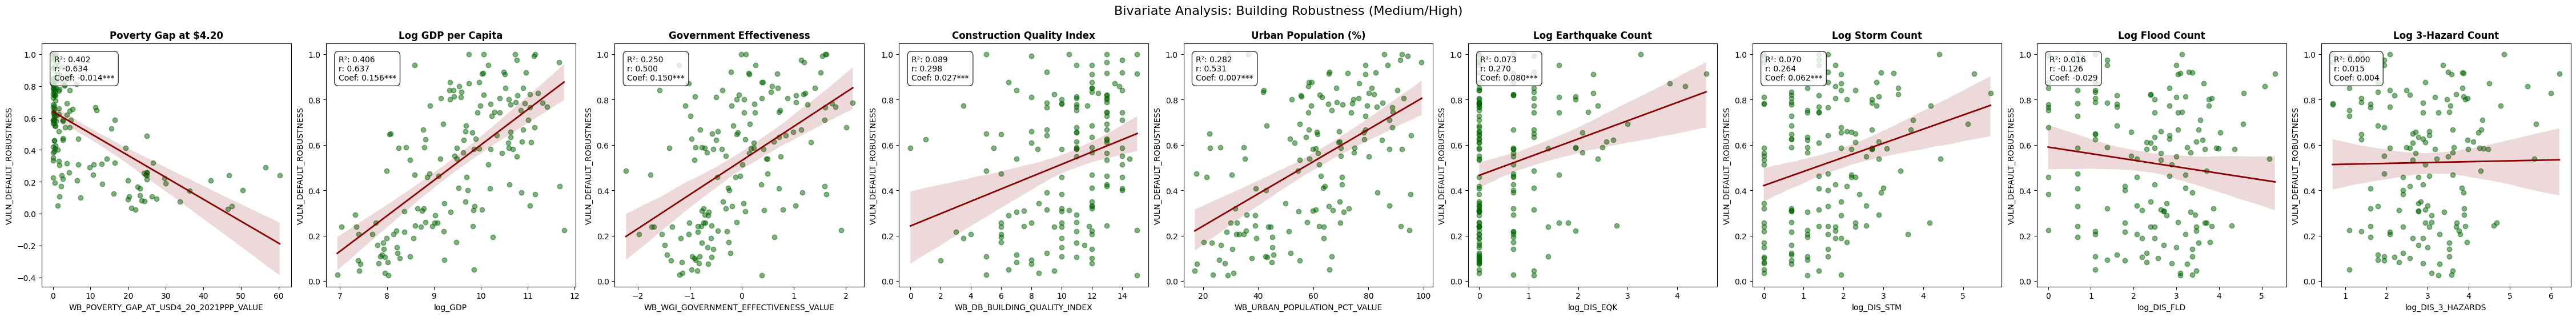

| IV                         | Coef       |   R-squared |   P-value |
|:---------------------------|:-----------|------------:|----------:|
| Poverty Gap at $4.20       | -0.0138*** |      0.4015 |    0      |
| Log GDP per Capita         | 0.1563***  |      0.4062 |    0      |
| Government Effectiveness   | 0.1503***  |      0.2499 |    0      |
| Construction Quality Index | 0.0272***  |      0.0886 |    0.0004 |
| Urban Population (%)       | 0.0071***  |      0.2818 |    0      |
| Log Earthquake Count       | 0.0803***  |      0.0729 |    0      |
| Log Storm Count            | 0.0622***  |      0.0697 |    0.0003 |
| Log Flood Count            | -0.0289    |      0.0159 |    0.1376 |
| Log 3-Hazard Count         | 0.0038     |      0.0002 |    0.8688 |

--- Running Analysis for DV: Building Robustness (Highest Only) ---


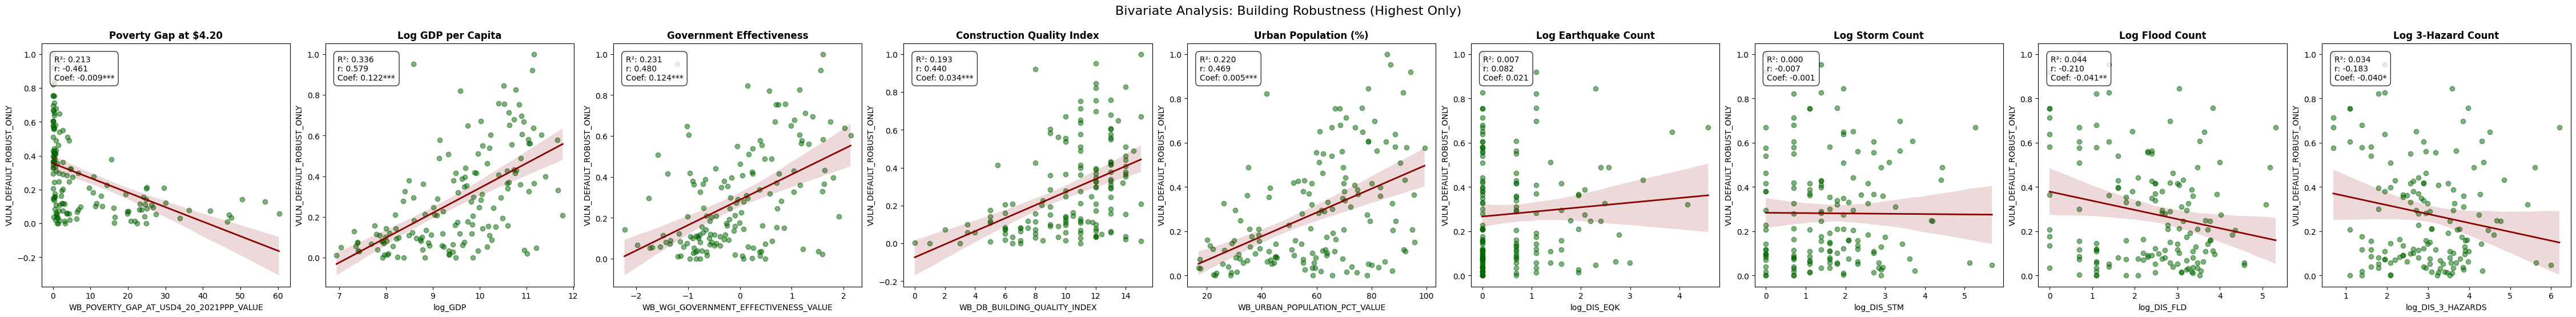

| IV                         | Coef       |   R-squared |   P-value |
|:---------------------------|:-----------|------------:|----------:|
| Poverty Gap at $4.20       | -0.0086*** |      0.2127 |    0      |
| Log GDP per Capita         | 0.1220***  |      0.3358 |    0      |
| Government Effectiveness   | 0.1240***  |      0.2307 |    0      |
| Construction Quality Index | 0.0345***  |      0.1934 |    0      |
| Urban Population (%)       | 0.0054***  |      0.2201 |    0      |
| Log Earthquake Count       | 0.0209     |      0.0067 |    0.3252 |
| Log Storm Count            | -0.0015    |      0.0001 |    0.9334 |
| Log Flood Count            | -0.0414**  |      0.0442 |    0.0289 |
| Log 3-Hazard Count         | -0.0402*   |      0.0337 |    0.0745 |


In [9]:
# =============================================================================
# 3. CORRELATION ANALYSIS & BIVARIATE REGRESSION
# =============================================================================

df_analysis_sub = df_stats.copy()

# -----------------------------------------------------------------------------
# PART A: CORRELATION MATRIX
# -----------------------------------------------------------------------------

correlation_vars = [
    'VULN_DEFAULT_ROBUSTNESS', 'VULN_DEFAULT_ROBUST_ONLY',
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE', 'log_GDP',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE', 'WB_DB_BUILDING_QUALITY_INDEX',
    'WB_URBAN_POPULATION_PCT_VALUE',
    'log_DIS_EQK', 'log_DIS_STM', 'log_DIS_FLD', 'log_DIS_3_HAZARDS',

]

corr_labels_short = {
    'VULN_DEFAULT_ROBUSTNESS': '(1) Robustness(M/H)', 'VULN_DEFAULT_ROBUST_ONLY': '(2) Robustness(H)',
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE': '(3) Poverty Gap', 'log_GDP': '(4) Log GDP p.c.',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE': '(5) Gov. Effectiveness', 'WB_DB_BUILDING_QUALITY_INDEX': '(6) Building Quality',
    'log_DIS_EQK': '(7) Log EQK', 'log_DIS_STM': '(8) Log STM', 'log_DIS_FLD': '(9) Log FLD', 'log_DIS_3_HAZARDS': '(10) Log 3-Haz',
    'WB_URBAN_POPULATION_PCT_VALUE': '(11) Urban Pop %',
}

def get_formatted_corr_matrix(df, vars, labels, lower_only=True):
    n = len(vars)
    rho = df[vars].corr()
    pval = pd.DataFrame(np.zeros((n, n)), index=vars, columns=vars)
    for i in range(n):
        for j in range(n):
            if i != j:
                _, p = pearsonr(df[vars[i]], df[vars[j]])
                pval.iloc[i, j] = p

    def star_format(r, p):
        if p < 0.01: s = '***'
        elif p < 0.05: s = '**'
        elif p < 0.10: s = '*'
        else: s = ''
        return f"{r:.3f}{s}"

    formatted_df = pd.DataFrame(index=[labels[v] for v in vars], columns=[labels[v] for v in vars])
    for i in range(n):
        for j in range(n):
            if lower_only and i < j:
                formatted_df.iloc[i, j] = ""
            else:
                formatted_df.iloc[i, j] = star_format(rho.iloc[i, j], pval.iloc[i, j])
    return formatted_df

# Generate and Export Correlation Matrix
corr_matrix_pub = get_formatted_corr_matrix(df_analysis_sub, correlation_vars, corr_labels_short)
print("\n" + "="*80 + "\nCORRELATION MATRIX (Lower Triangle)\n" + "="*80)
print(corr_matrix_pub.to_string())
corr_matrix_pub.to_csv(RESULTS_DATA_FOLDER / "correlation_matrix_publication.csv")

# -----------------------------------------------------------------------------
# PART B: SINGLE REGRESSION & SCATTERPLOTS
# -----------------------------------------------------------------------------

iv_map = {
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE': 'Poverty Gap at $4.20',
    'log_GDP': 'Log GDP per Capita',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE': 'Government Effectiveness',
    'WB_DB_BUILDING_QUALITY_INDEX': 'Construction Quality Index',
    'WB_URBAN_POPULATION_PCT_VALUE': 'Urban Population (%)',
    'log_DIS_EQK':'Log Earthquake Count',
    'log_DIS_STM':'Log Storm Count',
    'log_DIS_FLD':'Log Flood Count',
    'log_DIS_3_HAZARDS':'Log 3-Hazard Count',

}

dv_map = {
    'VULN_DEFAULT_ROBUSTNESS': 'Building Robustness (Medium/High)',
    'VULN_DEFAULT_ROBUST_ONLY': 'Building Robustness (Highest Only)'
}

def run_bivariate_analysis(df, dv_col, dv_label, iv_dict):
    n_ivs = len(iv_dict)
    fig, axes = plt.subplots(1, n_ivs, figsize=(n_ivs * 5, 5), constrained_layout=True)
    summary_list = []

    for i, (iv_col, iv_label) in enumerate(iv_dict.items()):
        # OLS Regression
        model = smf.ols(f"{dv_col} ~ {iv_col}", data=df).fit(cov_type='HC3')
        r2, p, coef = model.rsquared, model.pvalues[iv_col], model.params[iv_col]
        corr_r = df[dv_col].corr(df[iv_col])

        # Plotting
        ax = axes[i]
        sns.regplot(x=iv_col, y=dv_col, data=df, ax=ax,
                    scatter_kws={'alpha':0.5, 'color':'#006400'},
                    line_kws={'color':'darkred', 'lw':2})

        stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
        stats_text = f"R²: {r2:.3f}\nr: {corr_r:.3f}\nCoef: {coef:.3f}{stars}"
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.8))
        ax.set_title(f"{iv_label}", fontsize=12, fontweight='bold')

        summary_list.append({
            'IV': iv_label, 'Coef': f"{coef:.4f}{stars}", 'R-squared': round(r2, 4), 'P-value': round(p, 4)
        })

    plt.suptitle(f"Bivariate Analysis: {dv_label}", fontsize=16, y=1.08)
    plt.show()
    return pd.DataFrame(summary_list)

# Execution
for dv_key, dv_name in dv_map.items():
    print(f"\n--- Running Analysis for DV: {dv_name} ---")
    reg_summary = run_bivariate_analysis(df_analysis_sub, dv_key, dv_name, iv_map)
    print(reg_summary.to_markdown(index=False))



# Multiple regression

In [10]:
# Check list of World Bank Region
unique_regions = df_stats['REGION'].unique()

# Print the list of unique regions
print(unique_regions)

['Sub-Saharan Africa' 'Europe & Central Asia' 'Middle East & North Africa'
 'Latin America & Caribbean' 'East Asia & Pacific' 'South Asia'
 'North America']


In [11]:
# -----------------------------------------------------------------------------
# 0. DATA PREPARATION AND PRE-PROCESSING
# -----------------------------------------------------------------------------
df_multi_regress = df_stats.copy()

# Normalize hazards

POP_SCALE = 1_000_000

dis_vars = ['DIS_EQK', 'DIS_STM', 'DIS_FLD', 'DIS_3_HAZARDS']

for var in dis_vars:

    col_pop = f'log_{var}_per_POP'
    pop_density = df_multi_regress[var] / (df_multi_regress['WB_POPULATION_TOTAL_VALUE'] / POP_SCALE)
    df_multi_regress[col_pop] = np.log1p(pop_density)


for var in [f'log_{v}_per_POP' for v in dis_vars] :
    centered_name = f'C_{var}'
    df_multi_regress[centered_name] = df_multi_regress[var] - df_multi_regress[var].mean()


# Mean Centering

vars_to_center_map = {
    'log_GDP': 'C_log_GDP',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE': 'C_CWGI',
    'WB_DB_BUILDING_QUALITY_INDEX': 'C_CDBQ',
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE': 'C_POVERTY',
    'WB_URBAN_POPULATION_PCT_VALUE': 'C_URBAN',
    'log_Land_Area': 'C_log_LAND',
    'log_POP': 'C_log_POP',
    'log_DIS_EQK': 'C_log_DIS_EQK',
    'log_DIS_STM': 'C_log_DIS_STM',
    'log_DIS_FLD': 'C_log_DIS_FLD',
    'log_DIS_3_HAZARDS': 'C_log_DIS_3_HAZARDS'
}

for raw_var, centered_var_name in vars_to_center_map.items():
    if raw_var in df_multi_regress.columns:
        df_multi_regress[centered_var_name] = df_multi_regress[raw_var] - df_multi_regress[raw_var].mean()

# poverty squared
df_multi_regress['C_POVERTY_SQ'] = df_multi_regress['C_POVERTY'] ** 2


# -----------------------------------------------------------------------------
#  VIF DIAGNOSTICS
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("VIF DIAGNOSTICS")
print("=" * 80)

vif_test_vars = ['C_log_LAND', 'C_log_POP','C_URBAN', 'C_POVERTY', 'C_log_GDP', 'C_CWGI', 'C_CDBQ']
vif_data = df_multi_regress[vif_test_vars].dropna()

vif_results = pd.DataFrame()
vif_results["Variable"] = vif_test_vars
vif_results["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_test_vars))]
print(vif_results.to_string(index=False))


# -----------------------------------------------------------------------------
# 1. GENERIC OLS ANALYSIS FUNCTION
# -----------------------------------------------------------------------------

def run_ols_and_store(model_label: str, dependent_var: str, independent_vars: list, df: pd.DataFrame, fixed_effects: str = None):
    """Runs OLS regression with HC1 robust errors and returns the model object and metadata."""
    unique_vars = []
    [unique_vars.append(x) for x in independent_vars if x not in unique_vars]

    formula = f"{dependent_var} ~ {' + '.join(unique_vars)}"

    if fixed_effects:
        formula += f" + {fixed_effects}"
    try:
        model = smf.ols(formula=formula, data=df).fit(cov_type='HC1')
        return {
            'label': model_label,
            'model': model,
            'formula': formula,
            'DV': dependent_var,
        }

    except Exception as e:
        print(f"❌ WARNING: Model {model_label} failed. Details: {e}")
        return {'label': model_label, 'model': None, 'formula': formula, 'DV': dependent_var}

# -----------------------------------------------------------------------------
# 2. MODEL DEFINITION
# -----------------------------------------------------------------------------


all_models_results = []
REGION_FE = 'C(REGION)'

dependent_vars_list = [
    ('VULN_DEFAULT_ROBUSTNESS', 'VULN'),
    ('VULN_DEFAULT_ROBUST_ONLY', 'ONLY')
]

disaster_analysis_sets = [
    ('Multi_Raw', ['C_log_DIS_EQK', 'C_log_DIS_STM', 'C_log_DIS_FLD'], 'J+K+N'),
    ('Total_Raw', ['C_log_DIS_3_HAZARDS'], 'M'),
    ('Multi_Pop', ['C_log_DIS_EQK_per_POP', 'C_log_DIS_STM_per_POP', 'C_log_DIS_FLD_per_POP'], 'Jp+Kp+Np'),
    ('Total_Pop', ['C_log_DIS_3_HAZARDS_per_POP'], 'Mp')
]

adjusting_vars_list = [
    ('Poverty', 'C_POVERTY'),
    ('GDP', 'C_log_GDP'),
    ('Governance', 'C_CWGI'),
    ('Building Reg.', 'C_CDBQ'),
]


for dv_raw, dv_label in dependent_vars_list:
    print(f"\n>>> Running Strategic Analysis for DV: {dv_label}")

    # -------------------------------------------------------------------------
    # BLOCK A: STRUCTURAL NESTED STEPS
    # -------------------------------------------------------------------------
    m1_base = ['C_POVERTY']

    # Nasted steps
    m2_poverty = m1_base + [ 'C_POVERTY_SQ']
    m3_income  = m2_poverty + ['C_log_GDP']
    m4_urban   = m3_income + ['C_URBAN']
    m5_gov     = m4_urban + ['C_CWGI']
    m6_cbq  = m5_gov + ['C_CDBQ']

    structural_steps = [
        (f"{dv_label}-M1.Base",    m1_base),
        (f"{dv_label}-M2.Poverty", m2_poverty),
        (f"{dv_label}-M3.Income",  m3_income),
        (f"{dv_label}-M4.Urb",     m4_urban),
        (f"{dv_label}-M5.Gov",    m5_gov),
        (f"{dv_label}-M6.Full",    m6_cbq)
    ]

    for label, vars_list in structural_steps:
        all_models_results.append(run_ols_and_store(label, dv_raw, vars_list, df_multi_regress, fixed_effects=REGION_FE))

    # -------------------------------------------------------------------------
    # BLOCK B: DISASTER NESTED STEPS & INTERACTIONS
    # -------------------------------------------------------------------------
    for set_id, dis_vars, set_char in disaster_analysis_sets:

        # B-1. Disaster Nested Steps
        dis_nested_steps = [
            (f"D1.Pov",   m2_poverty + dis_vars),
            (f"D2.Econ",  m3_income + dis_vars),
            (f"D3.Urb",   m4_urban + dis_vars),
            (f"D4.Inst",  m5_gov + dis_vars),
            (f"D5.Policy", m6_cbq + dis_vars)
        ]

        for d_label, vars_list in dis_nested_steps:
            full_label = f"{dv_label}-{set_char}.{d_label}"
            all_models_results.append(run_ols_and_store(full_label, dv_raw, vars_list, df_multi_regress, fixed_effects=REGION_FE))

        # B-2. Interaction Models

        for adj_name, c_adjust_var in adjusting_vars_list:
            current_vars = list(set(m3_income + dis_vars + [c_adjust_var]))

            interaction_terms = [f"{c_adjust_var}:{dv}" for dv in dis_vars]
            final_vars = current_vars + interaction_terms

            adj_code = {"Poverty": "Int.Pov", "GDP": "Int.GDP", "Governance": "Int.WGI", "Building Reg.": "Int.BQCI"}[adj_name]
            full_label = f"{dv_label}-{set_char}.{adj_code}"

            all_models_results.append(run_ols_and_store(full_label, dv_raw, final_vars, df_multi_regress, fixed_effects=REGION_FE))

print(f"\n✅ All {len(all_models_results)} models completed successfully.")
# -----------------------------------------------------------------------------
# 4. VARIABLE LABELS AND FORMATTING
# -----------------------------------------------------------------------------

region_labels = {f'C(REGION)[T.{region_name}]': f'Region FE: {region_name}' for region_name in df_multi_regress['REGION'].unique()}

variable_map_en = {
    'Intercept': 'Constant',
    'C_URBAN': 'Urban Population %',
    'C_POVERTY': 'Poverty Gap ($4.20/day)',
    'C_POVERTY_SQ': 'Poverty Gap Squared',
    'C_log_GDP': 'Log GDP per Capita (PPP)',
    'C_CWGI': 'Government Effectiveness (WGI)',
    'C_CDBQ': 'Building Quality Index',
    'C_log_DIS_EQK': 'Earthquake Count (Log)',
    'C_log_DIS_STM': 'Storm Count (Log)',
    'C_log_DIS_FLD': 'Flood Count (Log)',
    'C_log_DIS_EQK_STM': 'Earthquake + Storm (Log)',
    'C_log_DIS_3_HAZARDS': '3 Hazards Combined (Log)',

    'C_log_DIS_EQK_per_POP': 'Earthquake Count (per Pop)',
    'C_log_DIS_STM_per_POP': 'Storm Count (per Pop)',
    'C_log_DIS_FLD_per_POP': 'Flood Count (per Pop)',
    'C_log_DIS_3_HAZARDS_per_POP': '3 Hazards (per Pop)',

    'C_POVERTY:C_log_DIS_EQK': 'Poverty × Earthquake',
    'C_POVERTY:C_log_DIS_STM': 'Poverty × Storm',
    'C_POVERTY:C_log_DIS_FLD': 'Poverty × Flood',
    'C_POVERTY:C_log_DIS_EQK_STM': 'Poverty × EQK+STM',
    'C_POVERTY:C_log_DIS_3_HAZARDS': 'Poverty × 3 Hazards',

    'C_log_DIS_EQK:C_log_GDP': 'GDP × Earthquake',
    'C_log_DIS_STM:C_log_GDP': 'GDP × Storm',
    'C_log_DIS_FLD:C_log_GDP': 'GDP × Flood',
    'C_log_DIS_EQK_STM:C_log_GDP': 'GDP × EQK+STM',
    'C_log_GDP:C_log_DIS_3_HAZARDS': 'GDP × 3 Hazards',

    'C_CWGI:C_log_DIS_EQK': 'Gov. Effectiveness × Earthquake',
    'C_CWGI:C_log_DIS_STM': 'Gov. Effectiveness × Storm',
    'C_CWGI:C_log_DIS_FLD': 'Gov. Effectiveness × Flood',
    'C_CWGI:C_log_DIS_EQK_STM': 'Gov. Effectiveness × EQK+STM',
    'C_CWGI:{CENTERED_3_HAZARDS_NAME}': 'Gov. Effectiveness × 3 Hazards',

    'C_CDBQ:C_log_DIS_EQK': 'Building Quality × Earthquake',
    'C_CDBQ:C_log_DIS_STM': 'Building Quality × Storm',
    'C_CDBQ:C_log_DIS_FLD': 'Building Quality × Flood',
    'C_CDBQ:C_log_DIS_EQK_STM': 'Building Quality × EQK+STM',
    'C_CDBQ:C_log_DIS_3_HAZARDS': 'Building Quality × 3 Hazards',

    **region_labels
}

info_dict = {
    'R-squared': lambda x: f'{x.rsquared:.4f}',
    'Adj. R-squared': lambda x: f'{x.rsquared_adj:.4f}',
    'Observations': lambda x: f'{int(x.nobs)}',
    'Region Fixed Effects': lambda x: 'Yes' if 'C(REGION)' in x.model.formula else 'No'
}

# -----------------------------------------------------------------------------
# 4. ORGANIZE AND EXPORT RESULTS
# -----------------------------------------------------------------------------

successful_results = [res for res in all_models_results if res['model'] is not None]
results_by_dv = {}
for dv_raw, _ in dependent_vars_list:
    results_by_dv[dv_raw] = [res for res in successful_results if res['DV'] == dv_raw]



VIF DIAGNOSTICS
  Variable      VIF
C_log_LAND 3.399418
 C_log_POP 3.544501
   C_URBAN 2.113780
 C_POVERTY 2.575329
 C_log_GDP 6.423993
    C_CWGI 3.033347
    C_CDBQ 1.652008

>>> Running Strategic Analysis for DV: VULN

>>> Running Strategic Analysis for DV: ONLY

✅ All 84 models completed successfully.


In [12]:
#  EXPORT  REGRESSION RESULTS

# -----------------------------------------------------------------------------
# 1. EXCEL Export
# -----------------------------------------------------------------------------

def export_to_excel_formatted(results_by_dv, variable_map_en, export_path):
    from openpyxl import Workbook
    from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
    from openpyxl.utils.dataframe import dataframe_to_rows

    wb = Workbook()
    wb.remove(wb.active)

    # Style
    header_fill = PatternFill(start_color="366092", end_color="366092", fill_type="solid")
    header_font = Font(bold=True, color="FFFFFF", size=11)
    sig_fill_001 = PatternFill(start_color="C6EFCE", end_color="C6EFCE", fill_type="solid")  # 0.01
    sig_fill_005 = PatternFill(start_color="FFEB9C", end_color="FFEB9C", fill_type="solid")  # 0.05
    sig_fill_010 = PatternFill(start_color="FFC7CE", end_color="FFC7CE", fill_type="solid")  # 0.10
    thin_border = Border(
        left=Side(style='thin'), right=Side(style='thin'),
        top=Side(style='thin'), bottom=Side(style='thin')
    )

    dv_sheet_names = {
        'VULN_DEFAULT_ROBUSTNESS': 'Composite Vulnerability',
        'VULN_DEFAULT_ROBUST_ONLY': 'Robustness Only',
        'VULN_EARTHQUAKE_ROBUSTNESS': 'EQK Robustness Total',
        'VULN_EARTHQUAKE_ROBUST_ONLY': 'EQK Robustness Only',
        'VULN_WIND_ROBUSTNESS': 'Wind Robustness Total',
        'VULN_WIND_ROBUST_ONLY': 'Wind Robustness Only',
    }

    for dv, sheet_name in dv_sheet_names.items():
        if dv not in results_by_dv or not results_by_dv[dv]:
            continue

        ws = wb.create_sheet(title=sheet_name[:31])
        results_list = results_by_dv[dv]

        # Data frame creation
        data_rows = []
        model_labels = []

        for res in results_list:
            if res['model'] is None:
                continue
            model = res['model']
            label = res['label']
            model_labels.append(label)

            # get vars
            for var in model.params.index:
                var_display = variable_map_en.get(var, var)
                coef = model.params[var]
                se = model.bse[var]
                pval = model.pvalues[var]

                stars = ''
                if pval < 0.01:
                    stars = '***'
                elif pval < 0.05:
                    stars = '**'
                elif pval < 0.10:
                    stars = '*'

                data_rows.append({
                    'Model': label,
                    'Variable': var_display,
                    'Coefficient': coef,
                    'Std. Error': se,
                    'P-Value': pval,
                    'Sig.': stars,
                    't-stat': coef / se if se != 0 else np.nan
                })

            data_rows.append({
                'Model': label, 'Variable': 'R-squared',
                'Coefficient': model.rsquared, 'Std. Error': '', 'P-Value': '', 'Sig.': '', 't-stat': ''
            })
            data_rows.append({
                'Model': label, 'Variable': 'Adj. R-squared',
                'Coefficient': model.rsquared_adj, 'Std. Error': '', 'P-Value': '', 'Sig.': '', 't-stat': ''
            })
            data_rows.append({
                'Model': label, 'Variable': 'Observations',
                'Coefficient': int(model.nobs), 'Std. Error': '', 'P-Value': '', 'Sig.': '', 't-stat': ''
            })

        df_export = pd.DataFrame(data_rows)

        ws.append(['Dependent Variable: ' + sheet_name])
        ws.append(['Estimation Method: OLS with HC1 Robust Standard Errors'])
        ws.append(['Significance: * p<0.10, ** p<0.05, *** p<0.01'])
        ws.append([])

        for r_idx, row in enumerate(dataframe_to_rows(df_export, index=False, header=True), start=5):
            ws.append(row)

            if r_idx == 5:
                for cell in ws[r_idx]:
                    cell.fill = header_fill
                    cell.font = header_font
                    cell.alignment = Alignment(horizontal='center', vertical='center')
            else:
                if len(row) > 4 and isinstance(row[4], (int, float)):
                    pval = row[4]
                    for cell in ws[r_idx]:
                        if pval < 0.01:
                            cell.fill = sig_fill_001
                        elif pval < 0.05:
                            cell.fill = sig_fill_005
                        elif pval < 0.10:
                            cell.fill = sig_fill_010

                for cell in ws[r_idx]:
                    cell.border = thin_border
                    cell.alignment = Alignment(horizontal='left', vertical='center')

        ws.column_dimensions['A'].width = 15
        ws.column_dimensions['B'].width = 35
        ws.column_dimensions['C'].width = 12
        ws.column_dimensions['D'].width = 12
        ws.column_dimensions['E'].width = 10
        ws.column_dimensions['F'].width = 8
        ws.column_dimensions['G'].width = 10

    try:
        wb.save(export_path)
        print(f"Complete Export as Excel: {export_path}")
        return True
    except Exception as e:
        print(f"Excel Export Error: {e}")
        return False

# -----------------------------------------------------------------------------
# 2. HTML Export
# -----------------------------------------------------------------------------

def export_to_html(results_by_dv, variable_map_en, export_path):
    # 1. Define strict hierarchical order
    preferred_order = [
        'C_POVERTY', 'C_POVERTY_SQ', 'C_log_GDP', 'C_URBAN', 'C_CWGI', 'C_CDBQ',
        'C_log_DIS_EQK', 'C_log_DIS_STM', 'C_log_DIS_FLD', 'C_log_DIS_3_HAZARDS',
        'C_log_DIS_EQK_per_POP', 'C_log_DIS_STM_per_POP', 'C_log_DIS_FLD_per_POP', 'C_log_DIS_3_HAZARDS_per_POP',
        'Intercept'
    ]

    order_map = {var: i for i, var in enumerate(preferred_order)}

    def get_sort_key(var_name):
        """
        Hierarchical sorting logic:
        1. Primary variables (0-999)
        2. Interaction terms grouped by adjusting variable (1000-7999)
        3. Regional Fixed Effects (9000-9998)
        4. Intercept (9999)
        """
        if var_name == 'Intercept':
            return 9999

        if 'C(REGION)' in var_name:
            return 9000 + (hash(var_name) % 1000) / 1000.0

        if ':' in var_name:
            parts = var_name.split(':')
            # Identify which part is the adjusting variable and which is the disaster variable
            # Sort based on the rank of adjusting variable first, then the disaster variable
            ranks = sorted([order_map.get(p, 8000) for p in parts])
            # primary_rank * 100 + secondary_rank ensures grouped sequential ordering
            return 1000 + (ranks[0] * 10) + (ranks[1] * 0.1)

        return order_map.get(var_name, 8000)

    # HTML Styles and Headers
    html_content = """
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="UTF-8">
        <title>Regression Analysis Report</title>
        <style>
            body { font-family: 'Segoe UI', Helvetica, Arial, sans-serif; margin: 30px; background-color: #f4f7f9; }
            h1 { color: #234f6e; border-bottom: 2px solid #234f6e; padding-bottom: 8px; }
            h2 { color: #2c3e50; margin-top: 40px; background: #e8eff2; padding: 10px; border-left: 6px solid #234f6e; }
            table { border-collapse: collapse; width: 100%; margin: 20px 0; background: white; font-size: 0.85em; }
            th { background-color: #234f6e; color: white; padding: 10px; text-align: center; position: sticky; top: 0; }
            td { padding: 6px 10px; border: 1px solid #d1d9e0; }
            tr:nth-child(even) { background-color: #f9f9f9; }
            .sig-001 { background-color: #d4edda !important; font-weight: bold; }
            .sig-005 { background-color: #fff3cd !important; }
            .sig-010 { background-color: #f8d7da !important; }
            .info-row { background-color: #e9ecef !important; font-weight: bold; }
            .number { text-align: right; font-family: 'Consolas', 'Courier New', monospace; white-space: nowrap; }
            .var-name { font-weight: bold; width: 300px; color: #333; }
        </style>
    </head>
    <body>
        <h1>Regression Analysis Results</h1>
    """

    dv_titles = {
        'VULN_DEFAULT_ROBUSTNESS': 'Composite Building Vulnerability Index',
        'VULN_DEFAULT_ROBUST_ONLY': 'Building Robustness ONLY Index'
    }

    for dv, title in dv_titles.items():
        if dv not in results_by_dv or not results_by_dv[dv]: continue

        results_list = results_by_dv[dv]
        existing_vars = set()
        for res in results_list:
            if res['model']: existing_vars.update(res['model'].params.index)

        # Apply hierarchical sort
        final_var_list = sorted(list(existing_vars), key=get_sort_key)

        html_content += f"<h2>Dependent Variable: {title}</h2>"
        html_content += "<table><thead><tr><th>Variable</th>"

        model_labels = [res['label'] for res in results_list if res['model']]
        for label in model_labels:
            html_content += f"<th>{label}</th>"
        html_content += "</tr></thead><tbody>"

        for var in final_var_list:
            var_display = variable_map_en.get(var, var)
            html_content += f"<tr><td class='var-name'>{var_display}</td>"

            for res in results_list:
                model = res['model']
                if model is None or var not in model.params.index:
                    html_content += "<td class='number'>-</td>"
                    continue

                coef, se, pval = model.params[var], model.bse[var], model.pvalues[var]
                stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
                css_class = 'sig-001' if pval < 0.01 else 'sig-005' if pval < 0.05 else 'sig-010' if pval < 0.10 else ''
                html_content += f"<td class='number {css_class}'>{coef:.4f}{stars}<br><small>({se:.4f})</small></td>"
            html_content += "</tr>"

        # Statistics block
        for stat_name in ['R-squared', 'Adj. R-squared', 'Observations']:
            html_content += f"<tr class='info-row'><td>{stat_name}</td>"
            for res in results_list:
                if res['model'] is None:
                    html_content += "<td class='number'>-</td>"
                    continue
                m = res['model']
                val = f"{m.rsquared:.4f}" if stat_name == 'R-squared' else \
                      f"{m.rsquared_adj:.4f}" if stat_name == 'Adj. R-squared' else f"{int(m.nobs)}"
                html_content += f"<td class='number'>{val}</td>"
            html_content += "</tr>"

        html_content += "</tbody></table>"

    html_content += "</body></html>"
    with open(export_path, 'w', encoding='utf-8') as f: f.write(html_content)
    return True

# -----------------------------------------------------------------------------
# 3. Pivot Style Excel Export (World Bank / Academic Style)
# -----------------------------------------------------------------------------

def export_to_excel_pivot(results_by_dv, variable_map_en, export_path):
    """
    Exports regression results in a publication-quality pivot format:
    Variables as rows, Models as columns, Standard Errors below Coefficients.
    """
    from openpyxl import Workbook
    from openpyxl.styles import Font, Alignment, Border, Side, PatternFill

    wb = Workbook()
    wb.remove(wb.active)

    # Styles
    header_font = Font(bold=True, size=11)
    stat_font = Font(italic=True, size=10)
    top_border = Border(top=Side(style='thick'))
    bottom_border = Border(bottom=Side(style='thin'))
    double_bottom_border = Border(bottom=Side(style='double'))
    align_center = Alignment(horizontal='center')
    align_left = Alignment(horizontal='left')

    # Sorting logic (Reuse the logic from HTML export for consistency)
    preferred_order = [
        'C_POVERTY', 'C_POVERTY_SQ', 'C_log_GDP', 'C_URBAN', 'C_CWGI', 'C_CDBQ',
        'C_log_DIS_EQK', 'C_log_DIS_STM', 'C_log_DIS_FLD', 'C_log_DIS_3_HAZARDS',
        'Intercept'
    ]
    order_map = {var: i for i, var in enumerate(preferred_order)}

    def get_sort_key(var_name):
        if var_name == 'Intercept': return 9999
        if 'C(REGION)' in var_name: return 9000 + (hash(var_name) % 1000) / 1000.0
        if ':' in var_name:
            parts = var_name.split(':')
            ranks = sorted([order_map.get(p, 8000) for p in parts])
            return 1000 + (ranks[0] * 10) + (ranks[1] * 0.1)
        return order_map.get(var_name, 8000)

    dv_sheet_names = {
        'VULN_DEFAULT_ROBUSTNESS': 'Composite Vulnerability',
        'VULN_DEFAULT_ROBUST_ONLY': 'Robustness Only',
        'VULN_EARTHQUAKE_ROBUSTNESS': 'EQK Robustness Total',
        'VULN_WIND_ROBUSTNESS': 'Wind Robustness Total',
    }

    for dv, sheet_name in dv_sheet_names.items():
        if dv not in results_by_dv or not results_by_dv[dv]:
            continue

        ws = wb.create_sheet(title=sheet_name[:31])
        results_list = [res for res in results_by_dv[dv] if res['model'] is not None]

        # Collect all variables across models and sort them
        all_vars = set()
        for res in results_list:
            all_vars.update(res['model'].params.index)
        sorted_vars = sorted(list(all_vars), key=get_sort_key)

        # 1. Headers
        ws.append([f"Table: Regression Results for {sheet_name}"])
        ws.append(["Dependent Variable: " + sheet_name])
        ws.append([])

        header_row = ["Variable"] + [res['label'] for res in results_list]
        ws.append(header_row)

        # Apply header styling
        for cell in ws[ws.max_row]:
            cell.font = header_font
            cell.border = top_border
            cell.alignment = align_center

        # 2. Main Coefficients and SEs
        for var in sorted_vars:
            var_display = variable_map_en.get(var, var)

            # Row 1: Coefficients
            coef_row = [var_display]
            for res in results_list:
                model = res['model']
                if var in model.params.index:
                    val = model.params[var]
                    pval = model.pvalues[var]
                    stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
                    coef_row.append(f"{val:.4f}{stars}")
                else:
                    coef_row.append("")
            ws.append(coef_row)

            # Row 2: Standard Errors
            se_row = [""]
            for res in results_list:
                model = res['model']
                if var in model.params.index:
                    se = model.bse[var]
                    se_row.append(f"({se:.4f})")
                else:
                    se_row.append("")
            ws.append(se_row)

        # 3. Summary Statistics
        stat_start_row = ws.max_row + 1
        stats = [
            ('Observations', lambda m: int(m.nobs)),
            ('R-squared', lambda m: f"{m.rsquared:.4f}"),
            ('Adj. R-squared', lambda m: f"{m.rsquared_adj:.4f}"),
            ('Regional FE', lambda m: "Yes" if any('REGION' in k for k in m.params.index) else "No")
        ]

        for stat_label, stat_func in stats:
            row = [stat_label]
            for res in results_list:
                row.append(stat_func(res['model']))
            ws.append(row)

            # Style for the first stat row (border top)
            if stat_label == 'Observations':
                for cell in ws[ws.max_row]:
                    cell.border = top_border

        # Footer
        ws.append([])
        ws.append(["Standard errors in parentheses"])
        ws.append(["* p<0.10, ** p<0.05, *** p<0.01"])

        # Border at the very bottom of the data
        for cell in ws[ws.max_row - 2]:
            cell.border = double_bottom_border

        # Column width adjustment
        ws.column_dimensions['A'].width = 40
        for i in range(2, len(header_row) + 1):
            char = chr(64 + i) if i <= 26 else 'A' + chr(64 + i - 26)
            ws.column_dimensions[char].width = 15
            for row in ws.iter_rows(min_row=4, max_row=ws.max_row):
                row[i-1].alignment = align_center

    try:
        wb.save(export_path)
        print(f"Complete Pivot Export: {excel_path_pivot}")
        return True
    except Exception as e:
        print(f"Pivot Export Error: {e}")
        return False


# -----------------------------------------------------------------------------
# 4. Run
# -----------------------------------------------------------------------------

base_path = os.path.join(RESULTS_DATA_FOLDER, "regression_results")

# 1. Excel
excel_path = base_path + "_formatted.xlsx"
export_to_excel_formatted(results_by_dv, variable_map_en, excel_path)

# 2. HTML
html_path = base_path + "_report.html"
export_to_html(results_by_dv, variable_map_en, html_path)

#3. Excel (pivot)
excel_path_pivot = base_path + "_pivot.xlsx"
export_to_excel_pivot(results_by_dv, variable_map_en, excel_path_pivot)


print("Export Completed")



Complete Export as Excel: /content/drive/MyDrive/Resilient_Housing_Global_Regression/Results/regression_results_formatted.xlsx
Complete Pivot Export: /content/drive/MyDrive/Resilient_Housing_Global_Regression/Results/regression_results_pivot.xlsx
Export Completed


# Robustness Check


In [15]:
# =============================================================================
# COMPREHENSIVE ROBUSTNESS CHECKS - COMPLETE VERSION
# All RCs include: Spec A (GDP) × DV (VULN, ONLY) + Spec B (Inst.) × DV (VULN, ONLY)
# =============================================================================

# --- A. INITIAL SETUP ---
robustness_models = []

# Ensure REGION is categorical
if 'REGION' in df_multi_regress.columns:
    df_multi_regress['REGION'] = df_multi_regress['REGION'].astype('category')
    print("\n✅ 'REGION' variable converted to categorical type for fixed effects.")
else:
    print("\n🛑 CRITICAL WARNING: 'REGION' column not found. Fixed effects will fail.")

# Define the fixed effect term
FE_TERM = " + C(REGION)"

# --- B. VARIABLE PREPARATION ---
print("\n" + "="*80)
print("VARIABLE PREPARATION FOR ROBUSTNESS CHECKS")
print("="*80)

try:
    print("\n[Prep] Coercing columns to numeric...")
    COLS_TO_CLEAN = [
        'MPI_HOUSING', 'DIS_EQK_DEATHS', 'DIS_STM_DEATHS', 'DIS_FLD_DEATHS',
        'WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE', 'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE',
        'WB_POVERTY_GAP_AT_USD3_00_2021PPP_VALUE','WB_POVERTY_GAP_AT_USD8_30_2021PPP_VALUE',
        'WB_POPULATION_TOTAL_VALUE', 'WB_GDP_PCAP_PPP_INTL_2021_VALUE',
        'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE', 'WB_DB_BUILDING_QUALITY_INDEX',
        'VULN_DEFAULT_ROBUST_ONLY', 'VULN_DEFAULT_ROBUSTNESS',
        'DIS_EQK', 'DIS_STM', 'DIS_FLD', 'DIS_3_HAZARDS',
        'DIS_EQK_DEATHS', 'DIS_FLD_DEATHS', 'DIS_STM_DEATHS',
        'VULN_DEFAULT_ROBUST_ONLY_WD', 'VULN_DEFAULT_ROBUSTNESS_WD'
    ]
    for col in COLS_TO_CLEAN:
        if col in df_multi_regress.columns:
            df_multi_regress[col] = pd.to_numeric(df_multi_regress[col], errors='coerce')
    print("✅ Numeric conversion complete.")

    print("[Prep] Creating centered and transformed variables...")
    # Core variables
    df_multi_regress['C_POVERTY'] = df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] - df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'].mean()
    df_multi_regress['log_GDP'] = np.log(df_multi_regress['WB_GDP_PCAP_PPP_INTL_2021_VALUE'])
    df_multi_regress['C_log_GDP'] = df_multi_regress['log_GDP'] - df_multi_regress['log_GDP'].mean()
    df_multi_regress['C_GOV_EFF'] = df_multi_regress['WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE'] - df_multi_regress['WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE'].mean()
    df_multi_regress['C_CDBQ'] = df_multi_regress['WB_DB_BUILDING_QUALITY_INDEX'] - df_multi_regress['WB_DB_BUILDING_QUALITY_INDEX'].mean()

    # Hazard variables
    HAZARDS = ['DIS_EQK', 'DIS_STM','DIS_FLD', 'DIS_3_HAZARDS','DIS_EQK_DEATHS', 'DIS_FLD_DEATHS', 'DIS_STM_DEATHS']
    for hazard in HAZARDS:
        df_multi_regress[f'log_{hazard}'] = np.log1p(df_multi_regress[hazard])
        df_multi_regress[f'C_log_{hazard}'] = df_multi_regress[f'log_{hazard}'] - df_multi_regress[f'log_{hazard}'].mean()

    # Alternative Dependent Variable
    df_multi_regress['ROB_MPI_HOUSING'] = 100 - df_multi_regress['MPI_HOUSING']
    print("✅ Variable preparation complete.")

except KeyError as e:
    print(f"🛑 CRITICAL WARNING: Missing column: {e}. Please ensure all original data variables are loaded.")

# --- C. DEFINE MODEL SPECIFICATIONS ---
# Specification A: Economic Model (GDP-focused)
SPEC_A_VARS = "C_log_GDP + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD"
# Specification B: Institutional Model (Governance-focused)
SPEC_B_VARS = "C_GOV_EFF + C_CDBQ + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD"



# --- D. ROBUSTNESS CHECKS ---

# =============================================================================
# RC0: Baseline (4 models)
# =============================================================================
print("\n[RC0] Baseline model...")

# RC0-A-VULN
robustness_models.append({'label': 'RC0-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Baseline (GDP Model)'})
# RC0-A-ONLY
robustness_models.append({'label': 'RC0-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Baseline  (GDP Model)'})
# RC0-B-VULN
robustness_models.append({'label': 'RC0-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Baseline  (Inst. Model)'})
# RC0-B-ONLY
robustness_models.append({'label': 'RC0-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Baseline  (Inst. Model)'})
print(f"✅ RC0 complete: 4 models estimated")




# =============================================================================
# RC1: ALTERNATIVE POVERTY - QUARTILES (4 models)
# =============================================================================
print("\n[RC1] Running: Alternative Poverty (Quartiles)...")
poverty_quantiles = df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'].quantile([0.25, 0.50, 0.75])
df_multi_regress['Poverty_Q2'] = ((df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] > poverty_quantiles[0.25]) & (df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] <= poverty_quantiles[0.50])).astype(int)
df_multi_regress['Poverty_Q3'] = ((df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] > poverty_quantiles[0.50]) & (df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] <= poverty_quantiles[0.75])).astype(int)
df_multi_regress['Poverty_Q4'] = (df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] > poverty_quantiles[0.75]).astype(int)
POV_QUARTILE_VARS = "Poverty_Q2 + Poverty_Q3 + Poverty_Q4"

# RC1-A-VULN
robustness_models.append({'label': 'RC1-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ {POV_QUARTILE_VARS} + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Quartiles (GDP Model)'})
# RC1-A-ONLY
robustness_models.append({'label': 'RC1-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ {POV_QUARTILE_VARS} + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Quartiles (GDP Model)'})
# RC1-B-VULN
robustness_models.append({'label': 'RC1-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ {POV_QUARTILE_VARS} + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Quartiles (Inst. Model)'})
# RC1-B-ONLY
robustness_models.append({'label': 'RC1-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ {POV_QUARTILE_VARS} + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Quartiles (Inst. Model)'})
print(f"✅ RC1 complete: 4 models estimated")

# =============================================================================
# RC2: ALTERNATIVE POVERTY - HEADCOUNT ($4.20) (4 models)
# =============================================================================
print("\n[RC2] Running: Alternative Poverty (Headcount $4.20)...")
if 'WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE' in df_multi_regress.columns:
    df_multi_regress['C_POVERTY_420'] = df_multi_regress['WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE'] - df_multi_regress['WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE'].mean()

    # RC2-A-VULN
    robustness_models.append({'label': 'RC2-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_420 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty HC $4.20 (GDP Model)'})
    # RC2-A-ONLY
    robustness_models.append({'label': 'RC2-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_420 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty HC $4.20 (GDP Model)'})
    # RC2-B-VULN
    robustness_models.append({'label': 'RC2-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_420 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty HC $4.20 (Inst. Model)'})
    # RC2-B-ONLY
    robustness_models.append({'label': 'RC2-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_420 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty HC $4.20 (Inst. Model)'})
    print(f"✅ RC2 complete: 4 models estimated")
else:
    print("⚠️ RC2 skipped: Poverty headcount data not available.")

# =============================================================================
# RC3: ALTERNATIVE POVERTY - GAP ($3.00) (4 models)
# =============================================================================
print("\n[RC3] Running: Alternative Poverty (Gap $3.00)...")
if 'WB_POVERTY_GAP_AT_USD3_00_2021PPP_VALUE' in df_multi_regress.columns:
    df_multi_regress['C_POVERTY_300'] = df_multi_regress['WB_POVERTY_GAP_AT_USD3_00_2021PPP_VALUE'] - df_multi_regress['WB_POVERTY_GAP_AT_USD3_00_2021PPP_VALUE'].mean()

    # RC3-A-VULN
    robustness_models.append({'label': 'RC3-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_300 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Gap $3.00 (GDP Model)'})
    # RC3-A-ONLY
    robustness_models.append({'label': 'RC3-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_300 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Gap $3.00 (GDP Model)'})
    # RC3-B-VULN
    robustness_models.append({'label': 'RC3-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_300 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Gap $3.00 (Inst. Model)'})
    # RC3-B-ONLY
    robustness_models.append({'label': 'RC3-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_300 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Gap $3.00 (Inst. Model)'})
    print(f"✅ RC3 complete: 4 models estimated")
else:
    print("⚠️ RC3 skipped: Poverty gap $3.00 data not available.")

# =============================================================================
# RC4: ALTERNATIVE POVERTY - GAP ($8.30) (4 models)
# =============================================================================
print("\n[RC4] Running: Alternative Poverty (Gap $8.30)...")
if 'WB_POVERTY_GAP_AT_USD8_30_2021PPP_VALUE' in df_multi_regress.columns:
    df_multi_regress['C_POVERTY_830'] = df_multi_regress['WB_POVERTY_GAP_AT_USD8_30_2021PPP_VALUE'] - df_multi_regress['WB_POVERTY_GAP_AT_USD8_30_2021PPP_VALUE'].mean()

    # RC4-A-VULN
    robustness_models.append({'label': 'RC4-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_830 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Gap $8.30 (GDP Model)'})
    # RC4-A-ONLY
    robustness_models.append({'label': 'RC4-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_830 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Gap $8.30 (GDP Model)'})
    # RC4-B-VULN
    robustness_models.append({'label': 'RC4-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_830 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Gap $8.30 (Inst. Model)'})
    # RC4-B-ONLY
    robustness_models.append({'label': 'RC4-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_830 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Gap $8.30 (Inst. Model)'})
    print(f"✅ RC4 complete: 4 models estimated")
else:
    print("⚠️ RC4 skipped: Poverty gap $8.30 data not available.")

# =============================================================================
# RC5: SAMPLE RESTRICTION - EXCLUDE SMALL STATES (4 models)
# =============================================================================
print("\n[RC5] Running: Sample Restriction (Exclude Small States)...")
if 'WB_POPULATION_TOTAL_VALUE' in df_multi_regress.columns:
    df_large = df_multi_regress[df_multi_regress['WB_POPULATION_TOTAL_VALUE'] > 1500000].copy()

    # RC5-A-VULN
    robustness_models.append({'label': 'RC5-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_large).fit(cov_type='HC1'), 'description': f'VULN-Exclude Small States (GDP, n={len(df_large)})'})
    # RC5-A-ONLY
    robustness_models.append({'label': 'RC5-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_large).fit(cov_type='HC1'), 'description': f'ONLY-Exclude Small States (GDP, n={len(df_large)})'})
    # RC5-B-VULN
    robustness_models.append({'label': 'RC5-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_large).fit(cov_type='HC1'), 'description': f'VULN-Exclude Small States (Inst., n={len(df_large)})'})
    # RC5-B-ONLY
    robustness_models.append({'label': 'RC5-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_large).fit(cov_type='HC1'), 'description': f'ONLY-Exclude Small States (Inst., n={len(df_large)})'})
    print(f"✅ RC5 complete: 4 models estimated")
else:
    print("⚠️ RC5 skipped: Population data not available.")

# =============================================================================
# RC6 & RC7: SAMPLE RESTRICTION - INCOME GROUPS (8 models total)
# =============================================================================
print("\n[RC6 & RC7] Running: Sample Restriction (Income Groups)...")
median_gdp = df_multi_regress['WB_GDP_PCAP_PPP_INTL_2021_VALUE'].median()

print(f"The median GDP per capita is: {median_gdp:.2f}")

df_low_income = df_multi_regress[df_multi_regress['WB_GDP_PCAP_PPP_INTL_2021_VALUE'] < median_gdp].copy()
df_high_income = df_multi_regress[df_multi_regress['WB_GDP_PCAP_PPP_INTL_2021_VALUE'] >= median_gdp].copy()

# Re-center variables for sub-samples
for df_sub in [df_low_income, df_high_income]:
    # Poverty (Centered and Squared)
    df_sub['C_POVERTY_sub'] = df_sub['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] - df_sub['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'].mean()
    df_sub['C_POVERTY_SQ_sub'] = df_sub['C_POVERTY_sub'] ** 2  # Corrected calculation

    # Urbanization (Centered)
    df_sub['C_URBAN_sub'] = df_sub['WB_URBAN_POPULATION_PCT_VALUE'] - df_sub['WB_URBAN_POPULATION_PCT_VALUE'].mean()

    # Other controls (Centered)
    df_sub['C_log_GDP_sub'] = np.log(df_sub['WB_GDP_PCAP_PPP_INTL_2021_VALUE']) - np.log(df_sub['WB_GDP_PCAP_PPP_INTL_2021_VALUE']).mean()
    df_sub['C_GOV_EFF_sub'] = df_sub['WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE'] - df_sub['WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE'].mean()
    df_sub['C_CDBQ_sub'] = df_sub['WB_DB_BUILDING_QUALITY_INDEX'] - df_sub['WB_DB_BUILDING_QUALITY_INDEX'].mean()


base_controls = "C_POVERTY_sub + C_POVERTY_SQ_sub + C_URBAN_sub"
disaster_vars = "C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD"

# --- RC6: Low/Lower-Middle Income (4 models) ---
# RC6-A-VULN
robustness_models.append({'label': 'RC6-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ {base_controls} + C_log_GDP_sub + {disaster_vars}{FE_TERM}", data=df_low_income).fit(cov_type='HC1'), 'description': f'VULN-Low/Lower-Middle Income (GDP, n={len(df_low_income)})'})
# RC6-A-ONLY
robustness_models.append({'label': 'RC6-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ {base_controls} + C_log_GDP_sub + {disaster_vars}{FE_TERM}", data=df_low_income).fit(cov_type='HC1'), 'description': f'ONLY-Low/Lower-Middle Income (GDP, n={len(df_low_income)})'})
# RC6-B-VULN
robustness_models.append({'label': 'RC6-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ {base_controls} + C_GOV_EFF_sub + C_CDBQ_sub + {disaster_vars}{FE_TERM}", data=df_low_income).fit(cov_type='HC1'), 'description': f'VULN-Low/Lower-Middle Income (Inst., n={len(df_low_income)})'})
# RC6-B-ONLY
robustness_models.append({'label': 'RC6-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ {base_controls} + C_GOV_EFF_sub + C_CDBQ_sub + {disaster_vars}{FE_TERM}", data=df_low_income).fit(cov_type='HC1'), 'description': f'ONLY-Low/Lower-Middle Income (Inst., n={len(df_low_income)})'})

# --- RC7: Upper-Middle/High Income (4 models) ---
# RC7-A-VULN
robustness_models.append({'label': 'RC7-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ {base_controls} + C_log_GDP_sub + {disaster_vars}{FE_TERM}", data=df_high_income).fit(cov_type='HC1'), 'description': f'VULN-Upper-Middle/High Income (GDP, n={len(df_high_income)})'})
# RC7-A-ONLY
robustness_models.append({'label': 'RC7-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ {base_controls} + C_log_GDP_sub + {disaster_vars}{FE_TERM}", data=df_high_income).fit(cov_type='HC1'), 'description': f'ONLY-Upper-Middle/High Income (GDP, n={len(df_high_income)})'})
# RC7-B-VULN
robustness_models.append({'label': 'RC7-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ {base_controls} + C_GOV_EFF_sub + C_CDBQ_sub + {disaster_vars}{FE_TERM}", data=df_high_income).fit(cov_type='HC1'), 'description': f'VULN-Upper-Middle/High Income (Inst., n={len(df_high_income)})'})
# RC7-B-ONLY
robustness_models.append({'label': 'RC7-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ {base_controls} + C_GOV_EFF_sub + C_CDBQ_sub + {disaster_vars}{FE_TERM}", data=df_high_income).fit(cov_type='HC1'), 'description': f'ONLY-Upper-Middle/High Income (Inst., n={len(df_high_income)})'})
print(f"✅ RC6 & RC7 complete: 8 models estimated")

# =============================================================================
# RC8: OUTLIER SENSITIVITY - EXCLUDE TOP 1% DISASTERS (4 models)
# =============================================================================
print("\n[RC8] Running: Outlier Sensitivity (Exclude Top 1% Disasters)...")
disaster_threshold = df_multi_regress['DIS_3_HAZARDS'].quantile(0.99)
df_no_outliers = df_multi_regress[df_multi_regress['DIS_3_HAZARDS'] < disaster_threshold].copy()

# RC8-A-VULN
robustness_models.append({'label': 'RC8-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_no_outliers).fit(cov_type='HC1'), 'description': f'VULN-Exclude Top 1% Disasters (GDP, n={len(df_no_outliers)})'})
# RC8-A-ONLY
robustness_models.append({'label': 'RC8-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_no_outliers).fit(cov_type='HC1'), 'description': f'ONLY-Exclude Top 1% Disasters (GDP, n={len(df_no_outliers)})'})
# RC8-B-VULN
robustness_models.append({'label': 'RC8-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_no_outliers).fit(cov_type='HC1'), 'description': f'VULN-Exclude Top 1% Disasters (Inst., n={len(df_no_outliers)})'})
# RC8-B-ONLY
robustness_models.append({'label': 'RC8-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_no_outliers).fit(cov_type='HC1'), 'description': f'ONLY-Exclude Top 1% Disasters (Inst., n={len(df_no_outliers)})'})
print(f"✅ RC8 complete: 4 models estimated")

# =============================================================================
# RC9: OUTLIER SENSITIVITY - WINSORIZE DISASTERS (P95) (4 models)
# =============================================================================
print("\n[RC9] Running: Outlier Sensitivity (Winsorize Disasters)...")
df_winsor = df_multi_regress.copy()
for hazard in ['DIS_EQK', 'DIS_STM', 'DIS_FLD']:
    p95 = df_winsor[hazard].quantile(0.95)
    df_winsor[hazard] = df_winsor[hazard].clip(upper=p95)
    df_winsor[f'log_{hazard}'] = np.log1p(df_winsor[hazard])
    df_winsor[f'C_log_{hazard}'] = df_winsor[f'log_{hazard}'] - df_winsor[f'log_{hazard}'].mean()

# RC9-A-VULN
robustness_models.append({'label': 'RC9-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_winsor).fit(cov_type='HC1'), 'description': 'VULN-Winsorized Disasters (GDP Model)'})
# RC9-A-ONLY
robustness_models.append({'label': 'RC9-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_winsor).fit(cov_type='HC1'), 'description': 'ONLY-Winsorized Disasters (GDP Model)'})
# RC9-B-VULN
robustness_models.append({'label': 'RC9-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_winsor).fit(cov_type='HC1'), 'description': 'VULN-Winsorized Disasters (Inst. Model)'})
# RC9-B-ONLY
robustness_models.append({'label': 'RC9-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_winsor).fit(cov_type='HC1'), 'description': 'ONLY-Winsorized Disasters (Inst. Model)'})
print(f"✅ RC9 complete: 4 models estimated")

# =============================================================================
# RC10: ALTERNATIVE DISASTER MEASURE - BINARY (4 models)
# =============================================================================
print("\n[RC10] Running: Alternative Disaster Measure (Binary)...")
df_multi_regress['EQK_any'] = (df_multi_regress['DIS_EQK'] > 0).astype(int)
df_multi_regress['STM_any'] = (df_multi_regress['DIS_STM'] > 0).astype(int)
df_multi_regress['FLD_any'] = (df_multi_regress['DIS_FLD'] > 0).astype(int)
BINARY_HAZARD_VARS = "EQK_any + STM_any + FLD_any"

# RC10-A-VULN
robustness_models.append({'label': 'RC10-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + C_log_GDP + {BINARY_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Binary Disasters (GDP Model)'})
# RC10-A-ONLY
robustness_models.append({'label': 'RC10-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + C_log_GDP + {BINARY_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Binary Disasters (GDP Model)'})
# RC10-B-VULN
robustness_models.append({'label': 'RC10-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + C_GOV_EFF + C_CDBQ + {BINARY_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Binary Disasters (Inst. Model)'})
# RC10-B-ONLY
robustness_models.append({'label': 'RC10-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + C_GOV_EFF + C_CDBQ + {BINARY_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Binary Disasters (Inst. Model)'})
print(f"✅ RC10 complete: 4 models estimated")

# =============================================================================
# RC10-2: ALTERNATIVE DISASTER MEASURE - Death
# =============================================================================
print("\n[RC10-2] Running: Alternative Disaster Measure (Death)...")
Death_HAZARD_VARS = "C_log_DIS_EQK_DEATHS + C_log_DIS_STM_DEATHS + C_log_DIS_FLD_DEATHS"

# RC10-2-A-VULN
robustness_models.append({'label': 'RC10-2-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + C_log_GDP + {Death_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Dealth Disasters (GDP Model)'})
# RC10-2-A-ONLY
robustness_models.append({'label': 'RC10-2-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + C_log_GDP + {Death_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Dealth Disasters (GDP Model)'})
# RC10-2-B-VULN
robustness_models.append({'label': 'RC10-2-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + C_GOV_EFF + C_CDBQ + {Death_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Dealth Disasters (Inst. Model)'})
# RC10-2-B-ONLY
robustness_models.append({'label': 'RC10-2-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + C_GOV_EFF + C_CDBQ + {Death_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Dealth Disasters (Inst. Model)'})
print(f"✅ RC10-2 complete: 4 models estimated")



# =============================================================================
# RC11: ALTERNATIVE DEPENDENT VARIABLE - MPI HOUSING (2 models - different DV)
# =============================================================================
print("\n[RC11] Running: Alternative Dependent Variable (MPI Housing)...")
# RC11-A (GDP Model)
robustness_models.append({'label': 'RC11-A-MPI', 'model': smf.ols(f"ROB_MPI_HOUSING ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: MPI Housing (GDP Model)'})
# RC11-B (Institutional Model)
robustness_models.append({'label': 'RC11-B-MPI', 'model': smf.ols(f"ROB_MPI_HOUSING ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: MPI Housing (Inst. Model)'})
print(f"✅ RC11 complete: 2 models estimated (different DV)")

# =============================================================================
# RC11-2: ALTERNATIVE DEPENDENT VARIABLE - Unit-weighted; instead of cost-weighted
# =============================================================================
print("\n[RC11-2] Running: Alternative Dependent Variable (Unit weighted)...")
# RC11-2-A (GDP Model)
robustness_models.append({'label': 'RC11-2-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS_WD ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: VULN-Unit weighted (GDP Model)'})
# RC11-2-A (GDP Model)
robustness_models.append({'label': 'RC11-2-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY_WD ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: ONLY-Unit weighted (GDP Model)'})

# RC11-2-2B (Institutional Model)
robustness_models.append({'label': 'RC11-2-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS_WD ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: VULN-Unit weighted (Inst. Model)'})
# RC11-2-B (Institutional Model)
robustness_models.append({'label': 'RC11-2-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY_WD ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: ONLY-Unit weighted (Inst. Model)'})

print(f"✅ RC11-2 complete: 4 models estimated (Unit-based)")

# =============================================================================
# RC12: REGIONAL HETEROGENEITY - JACKKNIFE
# =============================================================================
print("\n[RC12] Running: Regional Heterogeneity (Jackknife)...")
regions = df_multi_regress['REGION'].dropna().unique()
rc12_model_count = 0
for region in regions:
    # Ensure region name is file-safe for the label
    region_label = ''.join(e for e in region if e.isalnum())[:3].upper()

    df_excl = df_multi_regress[df_multi_regress['REGION'] != region].copy()

    # RC12-A-VULN (GDP Model)
    robustness_models.append({
        'label': f'RC12-A-{region_label}-VULN',
        'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_A_VARS} + C(REGION)", data=df_excl).fit(cov_type='HC1'),
        'description': f'VULN-Exclude {region} (GDP, n={len(df_excl)})'
    })
    # RC12-A-ONLY (GDP Model)
    robustness_models.append({
        'label': f'RC12-A-{region_label}-ONLY',
        'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_A_VARS} + C(REGION)", data=df_excl).fit(cov_type='HC1'),
        'description': f'ONLY-Exclude {region} (GDP, n={len(df_excl)})'
    })

    # RC12-B-VULN (Institutional Model)
    robustness_models.append({
        'label': f'RC12-B-{region_label}-VULN',
        'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_B_VARS} + C(REGION)", data=df_excl).fit(cov_type='HC1'),
        'description': f'VULN-Exclude {region} (Inst., n={len(df_excl)})'
    })
    # RC12-B-ONLY (Institutional Model)
    robustness_models.append({
        'label': f'RC12-B-{region_label}-ONLY',
        'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_B_VARS} + C(REGION)", data=df_excl).fit(cov_type='HC1'),
        'description': f'ONLY-Exclude {region} (Inst., n={len(df_excl)})'
    })
    rc12_model_count += 4

print(f"✅ RC12 complete: {rc12_model_count} models estimated (regional jackknife for VULN and ONLY)")




# --- E. SUMMARY TABLE GENERATION ---
print("\n" + "="*80)
print("GENERATING ROBUSTNESS CHECKS SUMMARY")
print("="*80)
print(f"\n📊 Total models estimated: {len(robustness_models)}")

detailed_results = []
for rc in robustness_models:
    model = rc['model']
    for var in model.params.index:
        detailed_results.append({
            'Model': rc['label'],
            'Description': rc['description'],
            'Variable': var,
            'Coefficient': model.params[var],
            'Std_Error': model.bse[var],
            'P_Value': model.pvalues[var],
            'Sig': '***' if model.pvalues[var] < 0.01 else ('**' if model.pvalues[var] < 0.05 else ('*' if model.pvalues[var] < 0.10 else ''))
        })

    # Add model stats
    detailed_results.append({'Model': rc['label'], 'Variable': 'R-squared', 'Coefficient': model.rsquared})
    detailed_results.append({'Model': rc['label'], 'Variable': 'Adj. R-squared', 'Coefficient': model.rsquared_adj})
    detailed_results.append({'Model': rc['label'], 'Variable': 'N', 'Coefficient': int(model.nobs)})

detailed_df = pd.DataFrame(detailed_results)

# --- F. EXPORT RESULTS ---

# Detailed Export
detailed_path = os.path.join(RESULTS_DATA_FOLDER, "RobustnessChecks_Detailed_Comprehensive.csv")
detailed_df.to_csv(detailed_path, index=False)
print(f"\n✅ Detailed results exported to: {detailed_path}")


def export_robustness_to_professional_excel(robustness_models, output_path):
    """
    Exports regression results to an Excel file with professional academic formatting
    and standardized English notes at the bottom.
    """
    print("\n" + "="*80)
    print("GENERATING PROFESSIONAL ACADEMIC TABLE WITH ENGLISH NOTES")
    print("="*80)

    # 1. Priority order for key variables
    PRIORITY_ORDER = [
        'Intercept',
        'C_POVERTY', 'C_POVERTY_420', 'C_POVERTY_300', 'C_POVERTY_830',
        'C_POVERTY_sub', 'Poverty_Q2', 'Poverty_Q3', 'Poverty_Q4',
        'C_log_GDP', 'C_log_GDP_sub', 'C_GOV_EFF', 'C_GOV_EFF_sub', 'C_CDBQ', 'C_CDBQ_sub',
        'C_log_DIS_EQK', 'C_log_DIS_STM', 'C_log_DIS_FLD',
        'EQK_any', 'STM_any', 'FLD_any',
        'C_log_DIS_EQK_DEATHS', 'C_log_DIS_STM_DEATHS', 'C_log_DIS_FLD_DEATHS'
    ]

    all_summaries = []
    found_variables = set()

    for rc in robustness_models:
        model = rc['model']
        label = rc['label']

        params = model.params
        bse = model.bse
        pvalues = model.pvalues

        def get_stars(p):
            if p < 0.01: return "***"
            if p < 0.05: return "**"
            if p < 0.10: return "*"
            return ""

        model_col = {}

        for var in params.index:
            if "C(REGION)" in var:
                continue

            found_variables.add(var)
            star = get_stars(pvalues[var])
            model_col[var] = f"{params[var]:.3f}{star}"
            model_col[f"{var}_se"] = f"({bse[var]:.3f})"

        # Statistics
        model_col['Observations'] = int(model.nobs)
        model_col['R-squared'] = f"{model.rsquared:.3f}"
        model_col['Adj. R-squared'] = f"{model.rsquared_adj:.3f}"
        model_col['Region Fixed Effects'] = "Yes" if "C(REGION)" in str(model.model.formula) else "No"

        all_summaries.append(pd.Series(model_col, name=label))

    # 2. Sort order logic
    remaining_vars = sorted(list(found_variables - set(PRIORITY_ORDER)))
    final_var_order = [v for v in PRIORITY_ORDER if v in found_variables] + remaining_vars

    # 3. DataFrame construction
    df_results = pd.concat(all_summaries, axis=1)
    sorted_rows = []
    for var in final_var_order:
        sorted_rows.append(var)
        if f"{var}_se" in df_results.index:
            sorted_rows.append(f"{var}_se")

    stats_rows = ['Observations', 'R-squared', 'Adj. R-squared', 'Region Fixed Effects']
    sorted_rows.extend([s for s in stats_rows if s in df_results.index])
    final_df = df_results.reindex(sorted_rows)

    # 4. Clean index names for display
    new_index = []
    for idx in final_df.index:
        if idx.endswith('_se'):
            new_index.append("")
        else:
            display_name = idx.replace('C_', '').replace('log_', 'Log ').replace('_', ' ')
            new_index.append(display_name)
    final_df.index = new_index

    # 5. Add English Notes at the bottom
    notes = [
        "",
        "Notes:",
        "1. Standard errors are reported in parentheses.",
        "2. Asterisks indicate statistical significance levels: * p < 0.10, ** p < 0.05, *** p < 0.01.",
        "3. Region Fixed Effects control for unobserved spatial heterogeneity across geographical clusters.",
        "4. All continuous variables are log-transformed where indicated by 'Log'."
    ]

    # Create a simple DataFrame for notes to append
    notes_df = pd.DataFrame(index=notes, columns=final_df.columns).fillna("")
    final_table = pd.concat([final_df, notes_df])

    # 6. Export to Excel
    try:
        with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
            final_table.to_excel(writer, sheet_name='Robustness_Results')

            # Format: Auto-adjust column width
            ws = writer.sheets['Robustness_Results']
            for col in ws.columns:
                max_length = 0
                column = col[0].column_letter
                for cell in col:
                    try:
                        if len(str(cell.value)) > max_length:
                            max_length = len(str(cell.value))
                    except: pass
                ws.column_dimensions[column].width = max_length + 4

        print(f"✅ Table with English notes saved to: {output_path}")
    except Exception as e:
        print(f" Export error: {e}")


RESULTS_EXCEL_PATH = os.path.join(RESULTS_DATA_FOLDER, "Table_Robustness_Checks.xlsx")
export_robustness_to_professional_excel(robustness_models, RESULTS_EXCEL_PATH)




✅ 'REGION' variable converted to categorical type for fixed effects.

VARIABLE PREPARATION FOR ROBUSTNESS CHECKS

[Prep] Coercing columns to numeric...
✅ Numeric conversion complete.
[Prep] Creating centered and transformed variables...
✅ Variable preparation complete.

[RC0] Baseline model...
✅ RC0 complete: 4 models estimated

[RC1] Running: Alternative Poverty (Quartiles)...
✅ RC1 complete: 4 models estimated

[RC2] Running: Alternative Poverty (Headcount $4.20)...
✅ RC2 complete: 4 models estimated

[RC3] Running: Alternative Poverty (Gap $3.00)...
✅ RC3 complete: 4 models estimated

[RC4] Running: Alternative Poverty (Gap $8.30)...
✅ RC4 complete: 4 models estimated

[RC5] Running: Sample Restriction (Exclude Small States)...
✅ RC5 complete: 4 models estimated

[RC6 & RC7] Running: Sample Restriction (Income Groups)...
The median GDP per capita is: 14884.81
✅ RC6 & RC7 complete: 8 models estimated

[RC8] Running: Outlier Sensitivity (Exclude Top 1% Disasters)...
✅ RC8 complete: 4